# Baseline Model: Logistic Regression
L'objectif de ce notebook est d'établir un modèle de référence (baseline) simple et interprétable pour la prédiction des résultats des matchs de Ligue 1 (H: Domicile, D: Nul, A: Extérieur).
Nous utiliserons une **Régression Logistique** sur notre dataset `ml_dataset.csv`.

Étapes :
1. Chargement des données
2. Nettoyage et encodage
3. Split temporel (Train sur les saisons passées, Test sur la saison actuelle)
4. Entraînement du modèle
5. Évaluation (Accuracy, Matrice de Confusion, Rapport de Classification)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import os

# Configuration de base
plt.style.use('ggplot')
sns.set_palette("husl")


In [2]:
# 1. Chargement du dataset
DATA_PATH = '../features/ml_dataset.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (7582, 23)


,match_id,season,gameweek,home_team,away_team,home_form_5,home_goals_scored_5,home_goals_conceded_5,home_offensive_str,home_defensive_str,...,away_goals_scored_5,away_goals_conceded_5,away_offensive_str,away_defensive_str,away_avg_overall,away_squad_value,odds_prob_home,odds_prob_draw,odds_prob_away,result
0,1,1999/00,NaN,rc-lens,paris-saint-germain,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0,NaN,NaN,NaN,D
1,2,2000/01,NaN,olympique-de-marseille,paris-saint-germain,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0,NaN,NaN,NaN,A
2,3,2000/01,NaN,rc-lens,olympique-de-marseille,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,73.85,58850000,NaN,NaN,NaN,D
3,4,1999/00,NaN,paris-saint-germain,olympique-de-marseille,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,73.85,58850000,NaN,NaN,NaN,H
4,5,1999/00,NaN,olympique-lyonnais,stade-de-reims,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,69.92,48600000,NaN,NaN,NaN,H


In [3]:
# 2. Préparation des données
# On retire les matchs qui n'ont pas de résultat (ex: matchs futurs)
df = df.dropna(subset=['result'])

# Features sélectionnées pour la baseline
features = [
    'home_form_5', 'away_form_5',
    'home_offensive_str', 'away_offensive_str',
    'home_defensive_str', 'away_defensive_str',
    'home_avg_overall', 'away_avg_overall',
    'home_squad_value', 'away_squad_value'
]

# Gestion des valeurs manquantes simples
df[features] = df[features].fillna(df[features].median())

X = df[features]
y = df['result']


In [4]:
# 3. Split Temporel
# On utilise la saison 2018/19 pour tester, et tout le reste pour entraîner.
test_season = '2018/19'

train_mask = df['season'] != test_season
test_mask = df['season'] == test_season

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train size: {len(X_train)} matchs")
print(f"Test size: {len(X_test)} matchs")

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 7186 matchs
Test size: 396 matchs


In [5]:
# 4. Entraînement de la Régression Logistique
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Modèle entraîné avec succès !")


Modèle entraîné avec succès !


In [6]:
# 5. Évaluation du modèle
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy sur la saison test ({test_season}) : {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy sur la saison test (2018/19) : 39.39%

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       102
           D       0.00      0.00      0.00       138
           H       0.39      1.00      0.57       156

    accuracy                           0.39       396
   macro avg       0.13      0.33      0.19       396
weighted avg       0.16      0.39      0.22       396



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

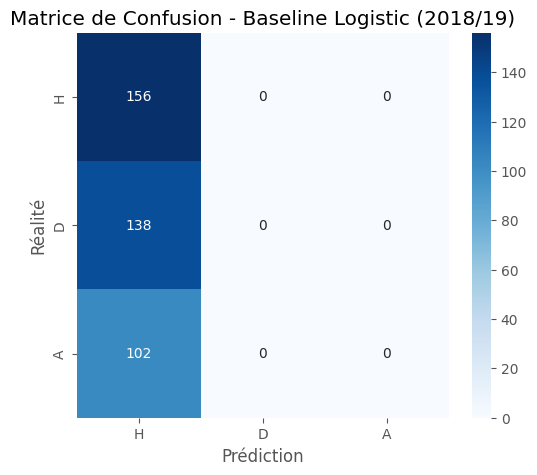

In [7]:
# Affichage de la matrice de confusion
labels = ['H', 'D', 'A']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title(f'Matrice de Confusion - Baseline Logistic ({test_season})')
plt.show()
